In [233]:
from exp_design import MaxDetFimExpDesign
%load_ext autoreload
%autoreload 2
import jax
# jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from jax import jit
from jax.scipy.linalg import expm

from qdots_qll.models.single_dot_weak_coupling_GAME import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [234]:
m = SingleDotWeakCouplingGAME()

In [235]:
true_parameters

Array([ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482], dtype=float32)

In [236]:
t = 25.4

In [237]:
m.likelihood_particle(true_parameters, t).shape

(4, 3, 2)

In [238]:
key = jax.random.PRNGKey(seed=1)

In [239]:
key, subkey = jax.random.split(key)
outcome = m.generate_data(subkey, true_parameters, t, 0, 2)

In [240]:
lkl = m.likelihood_particle(true_parameters, t)

In [241]:
lkl[0, 2, 0]

Array(0.37952685, dtype=float32)

In [242]:
# from qdots_qll.run import RunConditionalMeasurementsInitialStates
# RunConditionalMeasurementsInitialStates()


In [243]:
def est_par(pars, weights): return (weights[:, None] * pars).sum(0) / weights.sum(0)


def det_FIM(m, particle, t, dist_initial_states, dist_measurements):
    fim = m.fim(particle, t, dist_initial_states, dist_measurements)
    return jnp.linalg.det(fim)


def regularized_det_FIM(m, particle, t, dist_initial_states, dist_measurements):
    fim = m.fim(particle, t, dist_initial_states, dist_measurements)
    penalty = jnp.log(dist_initial_states) + jnp.log(dist_initial_state)
    return jnp.linalg.det(fim) + penalty.sum()


check_nan = jax.jit(lambda a: jax.lax.cond(jnp.isnan(a), lambda a: 0.0, lambda a: a, a))


In [244]:
from qdots_qll.resamplers import LWResampler

resampler = LWResampler(a=0.99)


In [245]:
# key = jax.random.PRNGKey(seed=1)
# 
# no_particles = 100
# no_parameters = 4
# 
# total_evol_rmse_runs = []
# for j in range(3):
#     evol_rmse = []
# 
#     initial_covariance = jnp.diagflat(jnp.ones(4) * 0.01) ** 1
#     particles_locations = jax.random.multivariate_normal(subkey, mean=true_parameters + 0.2, cov=initial_covariance,
#                                                          shape=(no_particles,))
#     weights = jnp.ones(no_particles)
# 
#     no_initial_states = 4
#     no_measurement_basis = 3
# 
#     dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
#     dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis
# 
#     for i in range(300):
#         print(f"Iteration {i}")
#         key, subkey = jax.random.split(key)
# 
#         t = jax.random.uniform(subkey, minval=0.1, maxval=100.)
#         # t = 25.4
# 
#         estimated_parameters = est_par(particles_locations, weights)
# 
#         grad_p_initial_state = jax.grad(det_FIM, 3)(m, estimated_parameters, t, dist_initial_state,
#                                                     dist_measurement_basis)
#         # print(grad_p_initial_state)
# 
#         grad_p_measurement_basis = jax.grad(det_FIM, 4)(m, estimated_parameters, t, dist_initial_state,
#                                                         dist_measurement_basis)
#         # print(grad_p_measurement_basis)
# 
#         dist_initial_state = dist_initial_state + grad_p_initial_state
#         dist_initial_state = dist_initial_state / dist_initial_state.sum()
# 
#         dist_measurement_basis = dist_measurement_basis + grad_p_measurement_basis
#         dist_measurement_basis = dist_measurement_basis / dist_measurement_basis.sum()
# 
#         key, subkey = jax.random.split(key)
# 
#         chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
#         key, subkey = jax.random.split(key)
# 
#         chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
#         key, subkey = jax.random.split(key)
# 
#         outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)
# 
#         lkl_particles = jax.vmap(lambda particle: m.likelihood_particle(particle, t)[*outcome])(particles_locations)
# 
#         lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)
# 
#         weights = weights * lkl_particles
#         weights = weights / weights.sum()
# 
#         evol_rmse.append(
#             mean_squared_error(estimated_parameters, true_parameters)
#         )
# 
#         if 1 / ((weights ** 2).sum()) <= no_particles / 2:
#             print("Resampling")
#             return_resampler = resampler.resample(key, particles_locations, weights)
#             key = return_resampler["key"]
#             weights = return_resampler["weights"]
#             particles_locations = return_resampler["particles_locations"]
# 
#     total_evol_rmse_runs.append(evol_rmse)
# 
# rmse_runs_adaptivity = total_evol_rmse_runs
# 
# key = jax.random.PRNGKey(seed=1)
# 
# no_particles = 1000
# no_parameters = 4
# 
# total_evol_rmse_runs = []
# for j in range(3):
#     evol_rmse = []
# 
#     initial_covariance = jnp.diagflat(jnp.ones(4) * 0.01) ** 1
#     particles_locations = jax.random.multivariate_normal(subkey, mean=true_parameters + 0.2, cov=initial_covariance,
#                                                          shape=(no_particles,))
#     weights = jnp.ones(no_particles) / no_particles
# 
#     no_initial_states = 4
#     no_measurement_basis = 3
# 
#     dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
#     dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis
# 
#     for i in range(300):
#         if i % 10 == 0:
#             print(f"Iteration {i}")
#         key, subkey = jax.random.split(key)
# 
#         t = jax.random.uniform(subkey, minval=0.1, maxval=100.)
#         # t = 25.4
# 
#         estimated_parameters = est_par(particles_locations, weights)
# 
#         key, subkey = jax.random.split(key)
# 
#         chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
#         key, subkey = jax.random.split(key)
# 
#         chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
#         key, subkey = jax.random.split(key)
# 
#         outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)
# 
#         lkl_particles = jax.vmap(lambda particle: m.likelihood_particle(particle, t)[*outcome])(particles_locations)
# 
#         lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)
# 
#         weights = weights * lkl_particles * dist_initial_state[chosen_initial_state] * dist_measurement_basis[
#             chosen_basis]
#         weights = weights / weights.sum()
# 
#         evol_rmse.append(
#             mean_squared_error(estimated_parameters, true_parameters)
#         )
# 
#         if 1 / ((weights ** 2).sum()) <= no_particles / 2:
#             print("Resampling")
#             return_resampler = resampler.resample(key, particles_locations, weights)
#             key = return_resampler["key"]
#             weights = return_resampler["weights"]
#             particles_locations = return_resampler["particles_locations"]
# 
#     total_evol_rmse_runs.append(evol_rmse)
# 
# rmse_runs_no_adaptivity = total_evol_rmse_runs
# 
# 
# 
# 


In [246]:
m

SingleDotWeakCouplingGAME(
  d=2,
  matrix_d=f32[2,2],
  positive_eps=1e-08,
  number_of_parameters=4,
  delta=0.12739334807998307,
  Omega=0.5,
  T=30,
  POVM_arr=c64[3,2,2,2],
  initial_states_bloch=f32[4,4],
  basis_elements=f32[4,4],
  trace_povm_G=f32[3,2,4]
)

In [247]:
true_parameters

Array([ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482], dtype=float32)

In [248]:
# rmse_runs_adaptivity = total_evol_rmse_runs

# rmse_runs_no_adaptivity = total_evol_rmse_runs

In [677]:
import equinox as eqx
import optax

In [805]:
class MaxDetFimExpDesign(eqx.Module):
    t_min: float
    t_max: float
    sgd_iter: int
    lr: float

    def __init__(self, t_min, t_max, sgd_iter, lr, *args, **kwargs) -> None:
        self.t_min = t_min
        self.t_max = t_max
        self.sgd_iter = sgd_iter
        self.lr = lr

    # @jit
    def utility_function( self, model, t,  **kwargs):
        fim = model.fim(t=t, **kwargs)
        return jnp.linalg.det(fim)
    


    # @jit
    def optimize_utility_function(
            self, model, t , **kwargs
    ):
        util_fun = lambda t: -1*jnp.linalg.det(model.fim(t=t, **kwargs))
        
        grad_f = jax.grad(util_fun, 0)
        # def grad_f(t):
        #     return -jax.grad(self.utility_function, 2)(
        #          model=model, t = t,  **kwargs
        #     )
    # 
        def f_for_scan(carry, x):
            params, opt_state = carry
            grad = grad_f(params)
            updates, opt_state = solver.update(grad, opt_state, params)
            params = optax.apply_updates(params, updates)
            return [params, opt_state], params

        solver = optax.adam(learning_rate=self.lr)
        params = t
        opt_state = solver.init(params)

        re = jax.lax.scan(f_for_scan, [params, opt_state], None, length=20)
        return re[0][0]
    # 
    @jit
    def generate_time(
            self,
            key,
            particles_locations,
            weights,
            model,
            **kwargs
    ):
        est_particle = est_mean(particles_locations, weights)

        util_fun = lambda t: -1*jnp.linalg.det(model.fim(t=t, particle=est_particle, **kwargs))
        
        no_candidates = 15

        key, subkey = jax.random.split(key)

        times_candidates = jax.random.uniform(
            subkey,
            shape=(no_candidates,),
            minval=self.t_min,
            maxval=self.t_max,
        )

        times_optimized = jax.vmap(
            lambda t: self.optimize_utility_function(
                model=model, t=t, particle=est_particle,  **kwargs
            )
        )(times_candidates)

        utilities = jax.vmap(
            lambda t: (
                util_fun(t)
            ),
        )(times_optimized)
        return times_optimized[jnp.argmax(utilities)]

In [806]:
expdesign = MaxDetFimExpDesign(0.1, 50., 10, 0.01)
expdesign.utility_function(model=m, t=t, particle=true_parameters, prob_initial_state=dist_initial_state, prob_measurement_basis=dist_measurement_basis)

Array(0.04468621, dtype=float32)

In [807]:
expdesign.optimize_utility_function(model=m, t=t, particle=true_parameters, prob_initial_state=dist_initial_state, prob_measurement_basis=dist_measurement_basis)

Array(25.200602, dtype=float32)

In [808]:
expdesign.generate_time(subkey, particles_locations, weights, model=m, prob_initial_state=dist_initial_state, prob_measurement_basis=dist_measurement_basis)

Array(44.88282, dtype=float32)

TypeError: differentiating with respect to argnums=1 requires at least 2 positional arguments to be passed by the caller, but got only 0 positional arguments.

TypeError: SingleDotWeakCouplingGAME.fim() missing 3 required positional arguments: 'particle', 'prob_initial_state', and 'prob_measurement_basis'

In [670]:
def example_f(*args, **kwargs):
    def f2(model):
        return print(model)

    f2(*args, **kwargs)
    # return model**2

In [679]:
def est_mean(particles_locations, weights):
    return jnp.einsum('ij, i-> j', particles_locations, weights)

In [686]:
est_par(particles_locations, weights)

Array([ 0.43556258,  0.4727675 ,  0.15237227, -0.21891661], dtype=float32)

In [687]:
est_mean(particles_locations, weights)

Array([ 0.43556258,  0.4727675 ,  0.15237227, -0.21891661], dtype=float32)

In [676]:


loss_f(m, particle=true_parameters, t=25.4, prob_initial_state=dist_initial_state,
       prob_measurement_basis=dist_measurement_basis)
# m.fim?

Array(0.04468621, dtype=float32)

In [671]:
example_f(model=4)

4


In [ ]:



n_time_candidates = 5
times_candidates = jax.random.uniform(subkey, minval=0.1, maxval=45., shape=(n_time_candidates,))

times_optimized = jax.vmap(
    lambda t: optimize_utility_function(
        t, estimated_particles, model
    )
)(times_candidates)

utilities = jax.vmap(
    lambda t: (
        self.utility_fun(model)(estimated_particles, t, initial_state)
    ),
)(times_optimized)
# return times_optimized[jnp.argmax(utilities)]



In [610]:
def step_adaptive(key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m):
    key, subkey = jax.random.split(key)
    t = jax.random.uniform(subkey, minval=0.1, maxval=45.)
    estimated_parameters = est_par(particles_locations, weights)

    grad_p_initial_state = jax.grad(det_FIM, 3)(m, estimated_parameters, t, dist_initial_state,
                                                dist_measurement_basis)
    # print(grad_p_initial_state)

    grad_p_measurement_basis = jax.grad(det_FIM, 4)(m, estimated_parameters, t, dist_initial_state,
                                                    dist_measurement_basis)

    grad_p_initial_state = grad_p_initial_state + jnp.abs(jnp.min(grad_p_initial_state))
    dist_initial_state = dist_initial_state + 0.01 * grad_p_initial_state / grad_p_initial_state.sum()
    # dist_initial_state = dist_initial_state + jnp.abs(jnp.min(dist_initial_state))
    dist_initial_state = dist_initial_state / dist_initial_state.sum()

    grad_p_measurement_basis = grad_p_measurement_basis + jnp.abs(jnp.min(grad_p_measurement_basis))

    dist_measurement_basis = dist_measurement_basis + 0.01 * grad_p_measurement_basis / grad_p_measurement_basis.sum()

    # dist_measurement_basis = dist_measurement_basis + jnp.abs(jnp.min(dist_measurement_basis))
    dist_measurement_basis = dist_measurement_basis / dist_measurement_basis.sum()

    key, subkey = jax.random.split(key)

    chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
    key, subkey = jax.random.split(key)

    chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
    key, subkey = jax.random.split(key)

    outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)

    lkl_particles = jax.vmap(lambda particle: m.likelihood_particle(particle, t)[*outcome])(particles_locations)

    lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)

    lkl_particles = lkl_particles * dist_initial_state[chosen_initial_state] * dist_measurement_basis[chosen_basis]

    weights = weights * lkl_particles
    weights = weights / weights.sum()

    # mean_squared_error(estimated_parameters, true_parameters)

    def true_fun(key, particles_locations, weights):
        return_resampler = resampler.resample(key, particles_locations, weights)
        key = return_resampler["key"]
        weights = return_resampler["weights"]
        particles_locations = return_resampler["particles_locations"]
        return key, particles_locations, weights

    def false_fun(key, particles_locations, weights):
        return key, particles_locations, weights

    key, particles_locations, weights = jax.lax.cond(1 / ((weights ** 2).sum()) <= no_particles / 2, true_fun,
                                                     false_fun, *[key, particles_locations, weights])

    return key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m


def step(key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m):
    key, subkey = jax.random.split(key)
    t = jax.random.uniform(subkey, minval=0.1, maxval=45.)
    # estimated_parameters = est_par(particles_locations, weights)
    # t = 25.4
    key, subkey = jax.random.split(key)

    chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
    key, subkey = jax.random.split(key)

    chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
    key, subkey = jax.random.split(key)

    outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)

    lkl_particles = jax.vmap(lambda particle: m.likelihood_particle(particle, t)[*outcome])(particles_locations)

    lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)

    lkl_particles = lkl_particles * dist_initial_state[chosen_initial_state] * dist_measurement_basis[chosen_basis]

    weights = weights * lkl_particles
    weights = weights / weights.sum()

    # mean_squared_error(estimated_parameters, true_parameters)

    def true_fun(key, particles_locations, weights):
        return_resampler = resampler.resample(key, particles_locations, weights)
        key = return_resampler["key"]
        weights = return_resampler["weights"]
        particles_locations = return_resampler["particles_locations"]
        return key, particles_locations, weights

    def false_fun(key, particles_locations, weights):
        return key, particles_locations, weights

    key, particles_locations, weights = jax.lax.cond(1 / ((weights ** 2).sum()) <= no_particles / 2, true_fun,
                                                     false_fun, *[key, particles_locations, weights])

    return key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m


In [611]:
step_adaptive_jit = jax.jit(step_adaptive)

step_jit = jax.jit(step)

In [612]:
t

25.4

In [613]:
@jit
def est_cov(particles_locations, weights):
    return jnp.einsum(
        "i, im, ik -> mk", weights, particles_locations, particles_locations
    ) - jnp.einsum(
        "i, ij, m, mk -> jk",
        weights,
        particles_locations,
        weights,
        particles_locations,
    )


In [614]:
# init = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m] 
# f must output carry, y , 
@jax.jit
def f_for_scan_non_adaptive(carry, _):
    key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m = step_jit(*carry)
    covariance = est_cov(particles_locations, weights)
    carry = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m]
    return carry, covariance


@jax.jit
def f_for_scan_adaptive(carry, _):
    key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m = step_adaptive_jit(*carry)
    covariance = est_cov(particles_locations, weights)
    carry = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m]
    return carry, covariance

In [638]:
key = jax.random.PRNGKey(seed=1)

no_particles = 100
no_parameters = 4

initial_covariance = jnp.diagflat(jnp.ones(4) * 0.01) ** 1
particles_locations = jax.random.multivariate_normal(subkey, mean=true_parameters + 0.1, cov=initial_covariance,
                                                     shape=(no_particles,))
weights = jnp.ones(no_particles)

no_initial_states = 4
no_measurement_basis = 3

dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis

In [654]:
no_runs = 10
max_iteration = 20000
key, subkey = jax.random.split(key)
subkeys = jax.random.split(subkey, no_runs)

In [655]:
# results_adaptive = jax.vmap(lambda key: jax.lax.scan(f_for_scan_adaptive,
#                                                      [key, particles_locations, weights, dist_initial_state,
#                                                       dist_measurement_basis, m],
#                                                      None, length=max_iteration))(subkeys)

results_adaptive = jax.vmap(lambda key: jax.lax.scan(f_for_scan_non_adaptive,
                                                     [key, particles_locations, weights, new_pars1,
                                                      new_pars2, m],
                                                     None, length=max_iteration))(subkeys)

results_non_adaptive = jax.vmap(lambda key: jax.lax.scan(f_for_scan_non_adaptive,
                                                         [key, particles_locations, weights, dist_initial_state,
                                                          dist_measurement_basis, m],
                                                         None, length=max_iteration))(subkeys)

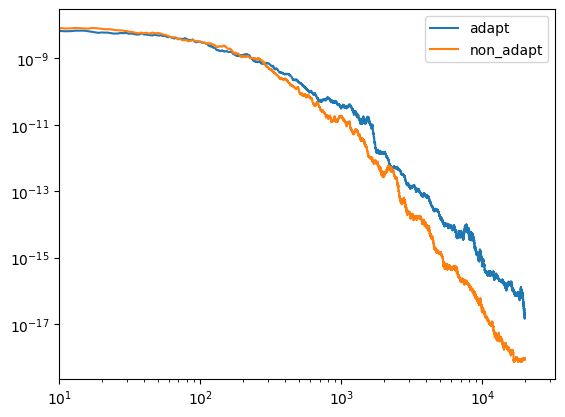

In [656]:
plt.plot(jax.vmap(lambda a: jax.vmap(lambda a: jnp.linalg.det(a))(a))(results_adaptive[1]).mean(axis=0), label='adapt')
plt.plot(jax.vmap(lambda a: jax.vmap(lambda a: jnp.linalg.det(a))(a))(results_non_adaptive[1]).mean(axis=0),
         label='non_adapt')
plt.loglog()
plt.xlim(1e1)
plt.legend()
plt.show()

In [662]:
print(jnp.mean(jax.vmap(lambda a, b: est_par(a, b), in_axes=(0, 0))(results_adaptive[0][1], results_adaptive[0][2]),
               axis=0))
print(jnp.mean(
    jax.vmap(lambda a, b: est_par(a, b), in_axes=(0, 0))(results_non_adaptive[0][1], results_non_adaptive[0][2]),
    axis=0))

[ 0.33247134  0.39055195  0.10833229 -0.24636845]
[ 0.37702414  0.41199112  0.09215628 -0.27458486]


In [660]:
true_parameters

Array([ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482], dtype=float32)

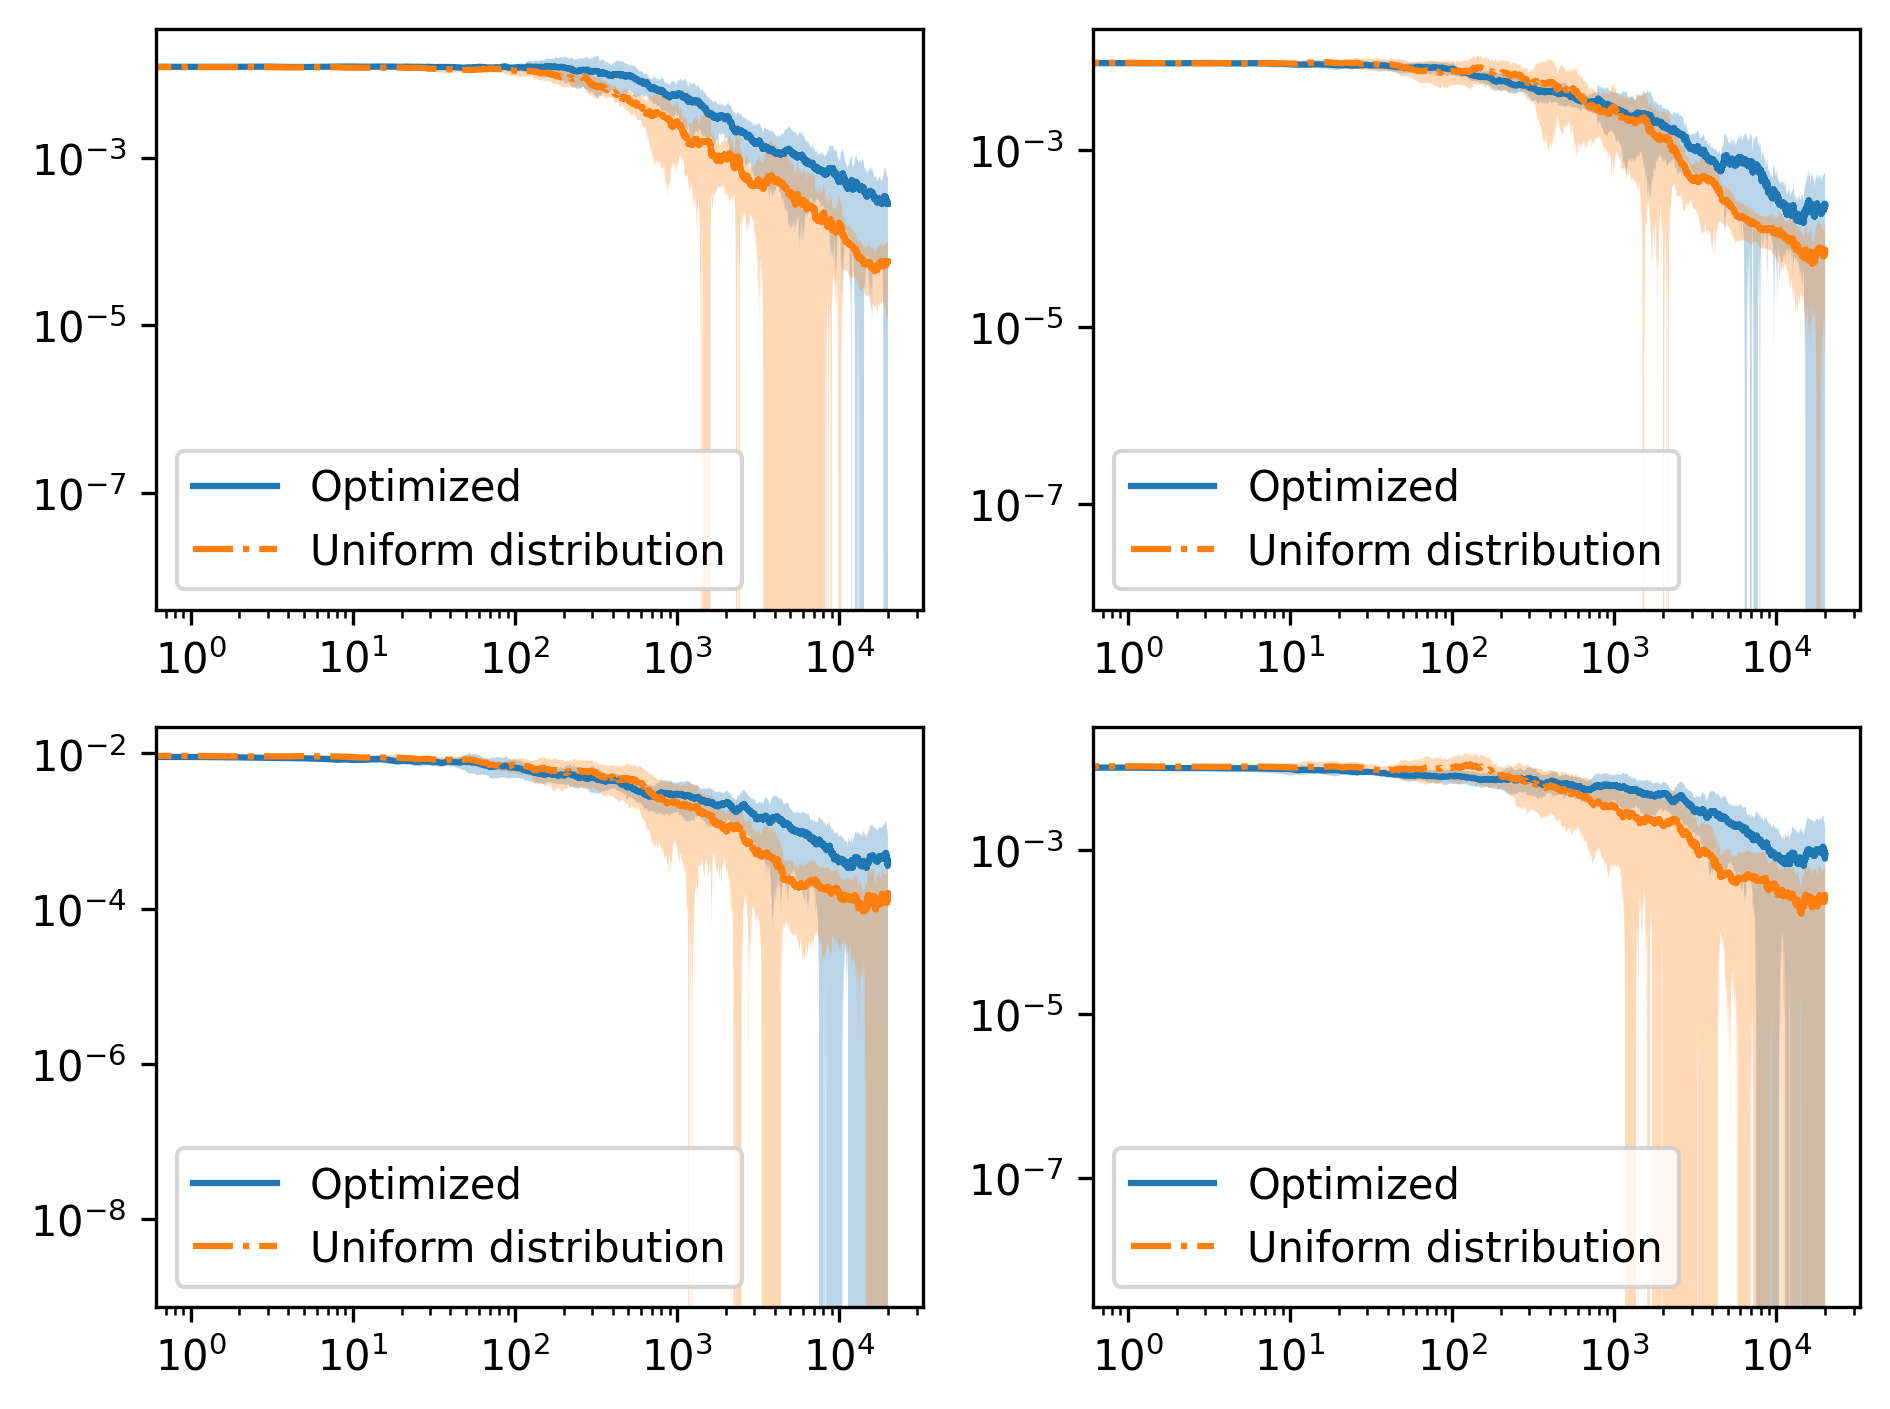

In [663]:
fig, axs = plt.subplots(2, 2, dpi=300)
x = jnp.arange(max_iteration)
for i, ax in enumerate(axs.flatten()):
    ax.plot(x, jnp.mean(results_adaptive[1], axis=0)[:, i, i], '-', label='Optimized')

    ax.fill_between(x=x,
                    y1=jnp.mean(results_adaptive[1], axis=0)[:, i, i] - jnp.nanstd(results_adaptive[1], axis=0)[:, i,
                                                                        i],
                    y2=jnp.mean(results_adaptive[1], axis=0)[:, i, i] + jnp.nanstd(results_adaptive[1], axis=0)[:, i,
                                                                        i], alpha=0.3)

    ax.plot(x, jnp.mean(results_non_adaptive[1], axis=0)[:, i, i], '-.', label="Uniform distribution")
    # 
    ax.fill_between(x=x,
                    y1=jnp.mean(results_non_adaptive[1], axis=0)[:, i, i] - jnp.nanstd(results_non_adaptive[1], axis=0)[
                                                                            :, i, i],
                    y2=jnp.mean(results_non_adaptive[1], axis=0)[:, i, i] + jnp.nanstd(results_non_adaptive[1], axis=0)[
                                                                            :, i, i], alpha=0.3)
    ax.loglog()
    ax.legend()

plt.tight_layout()
plt.show()

# Cacharreo with Solver



In [256]:
from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

In [457]:
# the function to miminize should be the minus determinant with


def loss_f_initial_state(dist_initial_state, m, particle, t, dist_measurements):
    fim = m.fim(particle, t, dist_initial_state, dist_measurements)
    return -jnp.linalg.det(fim)
    # return -jnp.trace(fim)


def loss_f_measurement_basis(dist_measurements, m, particle, t, dist_initial_state):
    fim = m.fim(particle, t, dist_initial_state, dist_measurements)
    return -jnp.linalg.det(fim)
    # return -jnp.trace(fim)


In [458]:
pg1 = ProjectedGradient(fun=loss_f_initial_state, projection=projection_simplex, verbose=True, stepsize=0.1)

pg2 = ProjectedGradient(fun=loss_f_measurement_basis, projection=projection_simplex, verbose=True, stepsize=0.1)


# pg_init_state = pg1.init_state(dist_initial_state, m=m, particle=true_parameters, t=t, dist_measurements=dist_measurement_basis)
# new_params = dist_initial_state
# new_state = pg_init_state

In [459]:
pg1_init_state = pg1.init_state(dist_initial_state, m=m, particle=true_parameters, t=t,
                                dist_measurements=dist_measurement_basis)

pg2_init_state = pg1.init_state(dist_measurement_basis, m=m, particle=true_parameters, t=t,
                                dist_initial_state=dist_initial_state)

new_pars1 = dist_initial_state
new_pars2 = dist_measurement_basis

new_state1 = pg1_init_state
new_state2 = pg2_init_state

In [488]:
new_pars1, new_state1 = pg1.update(new_pars1, state=new_state1, m=m, particle=true_parameters, t=t,
                                   dist_measurements=new_pars2)

new_pars2, new_state2 = pg2.update(new_pars2, state=new_state2, m=m, particle=true_parameters, t=t,
                                   dist_initial_state=new_pars1)

print(new_pars1)
print(new_pars2)

aux = m.fim(true_parameters, t, new_pars1, new_pars2)
print(aux)
print(jnp.linalg.det(aux))

INFO: jaxopt.ProximalGradient: Iter: 29 Distance btw Iterates (stop. crit.): 1.2908225471619517e-05 Stepsize:0.10000000149011612 
INFO: jaxopt.ProximalGradient: Iter: 29 Distance btw Iterates (stop. crit.): 0.0 Stepsize:0.10000000149011612 
[0.45222816 0.27473953 0.         0.27303216]
[0. 0. 1.]
[[ 2.311584   -0.53410447  0.7638892   0.73950505]
 [-0.53410447  2.0673923   0.7270173   0.7687318 ]
 [ 0.7638892   0.7270173   0.77273965  0.69192415]
 [ 0.73950505  0.7687318   0.69192415  2.1335502 ]]
0.6502322


In [532]:
jnp.linalg.eigh(aux)[0]

Array([0.07019244, 0.9643627 , 2.7229092 , 3.527801  ], dtype=float32)

In [531]:
jnp.linalg.eigh(m.fim(true_parameters, t, dist_initial_state, dist_measurement_basis))[0]

Array([0.03226678, 0.53936106, 1.4863738 , 1.7274673 ], dtype=float32)

In [495]:
# pg.run(dist_initial_state, m=m, particle=true_parameters, t=t, dist_measurements=dist_measurement_basis)

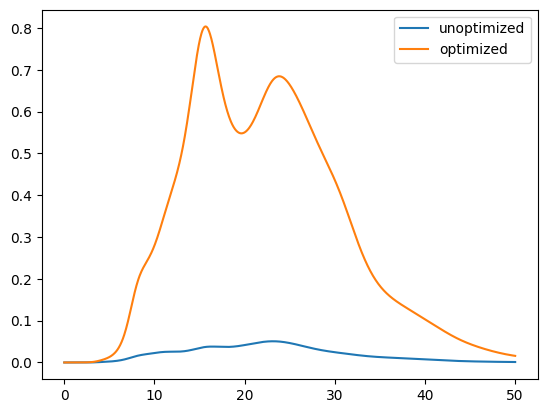

In [527]:


times = jnp.linspace(0, 50, 1000)

detfimtimes = jax.vmap(lambda t: jnp.linalg.det(m.fim(true_parameters, t, dist_initial_state, dist_measurement_basis)))(
    times)

new_detfimtimes = jax.vmap(
    lambda t: jnp.linalg.det(m.fim(true_parameters, t, new_pars1, new_pars2)))(times)

plt.plot(times, detfimtimes, label="unoptimized")
plt.plot(times, new_detfimtimes, label='optimized')
plt.legend()
